Project In-depth Data Exploration and Preparation - 7-11-2026 - DAMHAR2570

In [1]:
# Import necessary libraries
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the Penguin dataset
data = pd.read_csv('C:/Users/ecpi/Downloads/penguins.csv')

# Display the first few rows to understand what the data looks like
display(Markdown("### Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Load the Dataset

Date: 2026-07-11

Student ID: DAMHAR2570

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [2]:
display(Markdown("### Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Get a concise summary of the DataFrame
print(data.info())

# Get descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's numerical features
display(data.describe())

### Initial Exploration of the Dataset

Date: 2026-07-11

Student ID: DAMHAR2570

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB
None


,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,171.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,0.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,85.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,171.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,257.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,343.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [3]:
display(Markdown("### Data Cleaning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")

# Fill missing values for 'bill_length_mm' with the median bill length
data['bill_length_mm'] = data['bill_length_mm'].fillna(data['bill_length_mm'].mean())

# Fill missing values for 'bill_depth_mm' with the median bill depth
data['bill_depth_mm'] = data['bill_depth_mm'].fillna(data['bill_depth_mm'].median())

# Fill missing values for 'flipper_length_mm' with the median flipper length
data['flipper_length_mm'] = data['flipper_length_mm'].fillna(data['flipper_length_mm'].median())

# Fill missing values for 'body_mass_g' with the median body_mass_g
data['body_mass_g'] = data['body_mass_g'].fillna(data['body_mass_g'].median())

# Fill missing values for 'sex' with the most common sex
data['sex'] = data['sex'].fillna(data['sex'].mode()[0])

data.drop(columns=['id', 'year'], inplace=True)

# Verify that there are no remaining missing values
missing_values_after = data.isnull().sum()
print(f"Missing values after cleaning:\n{missing_values_after}")

### Data Cleaning

Date: 2026-07-11

Student ID: DAMHAR2570

Missing values in each column:
id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### Univariate Analysis

Date: 2026-07-11

Student ID: DAMHAR2570


--- Histograms of Numerical Features ---


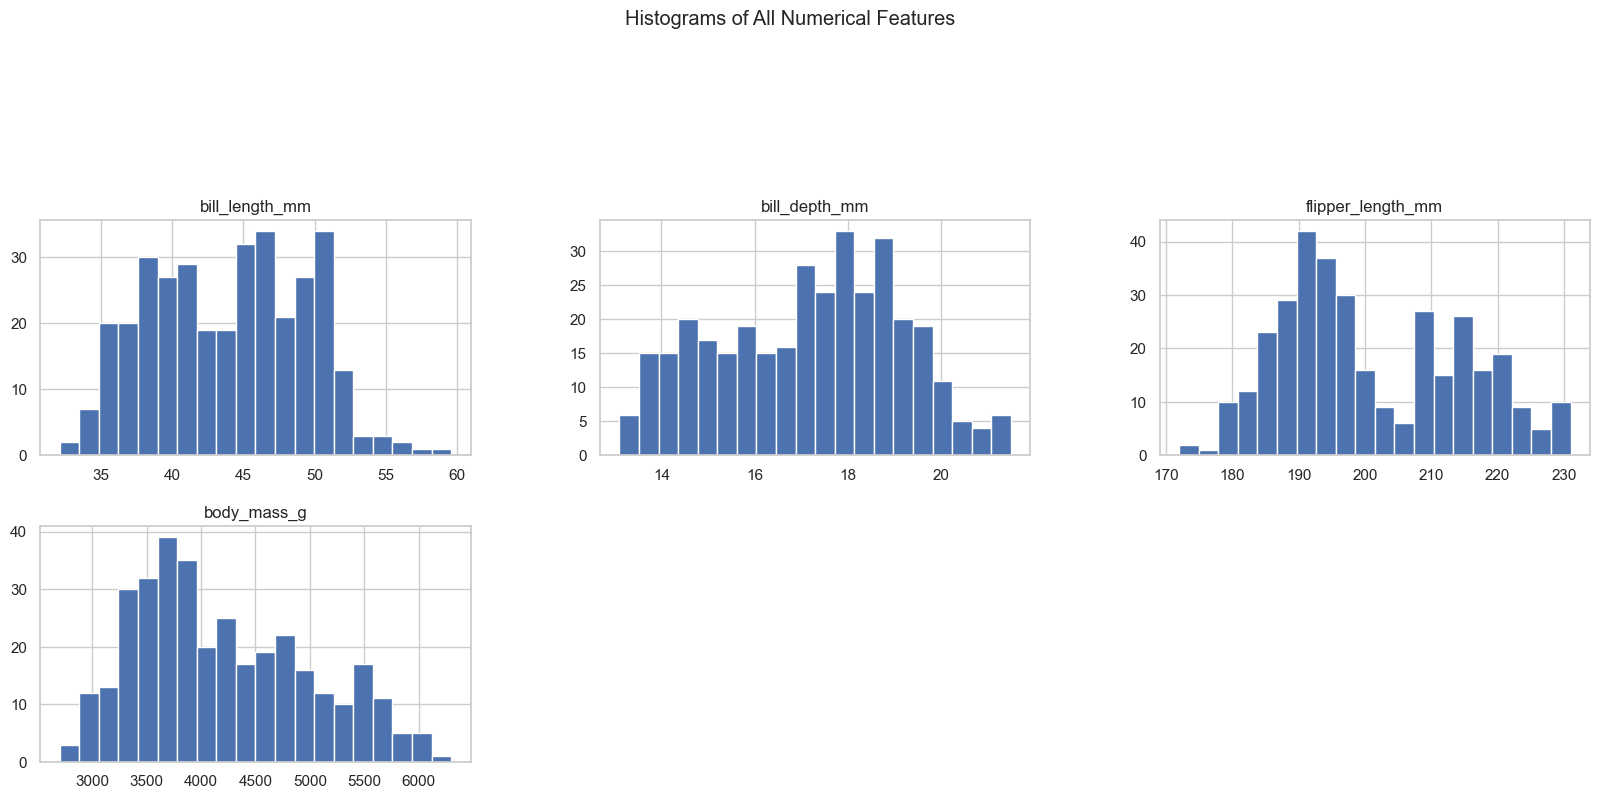

In [4]:
# Univariate Analysis
display(Markdown("### Univariate Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
sns.set(style="whitegrid")

# Histograms
print("\n--- Histograms of Numerical Features ---")
data.hist(bins=20, figsize=(20, 15), layout=(4, 3))
plt.suptitle('Histograms of All Numerical Features', y=1.02)
plt.show()

Date: 2026-07-11

Student ID: DAMHAR2570


--- Feature Distributions by Species ---


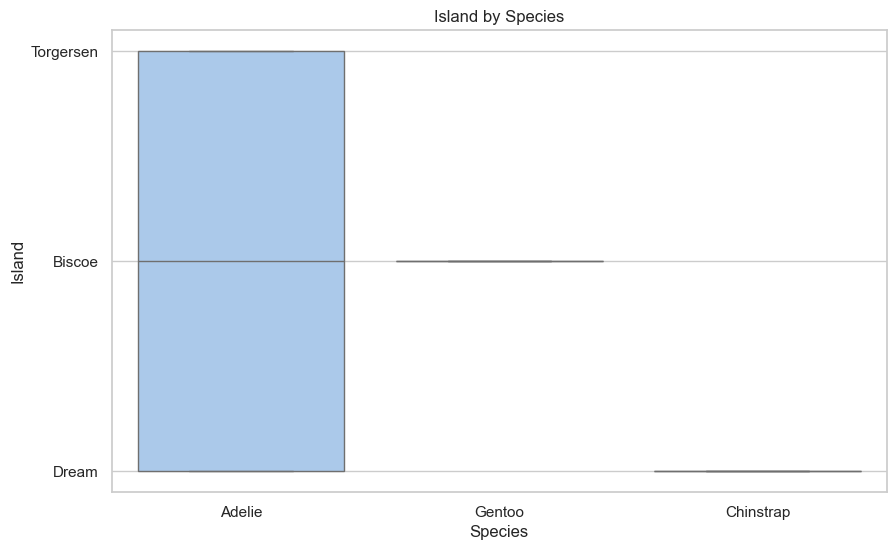

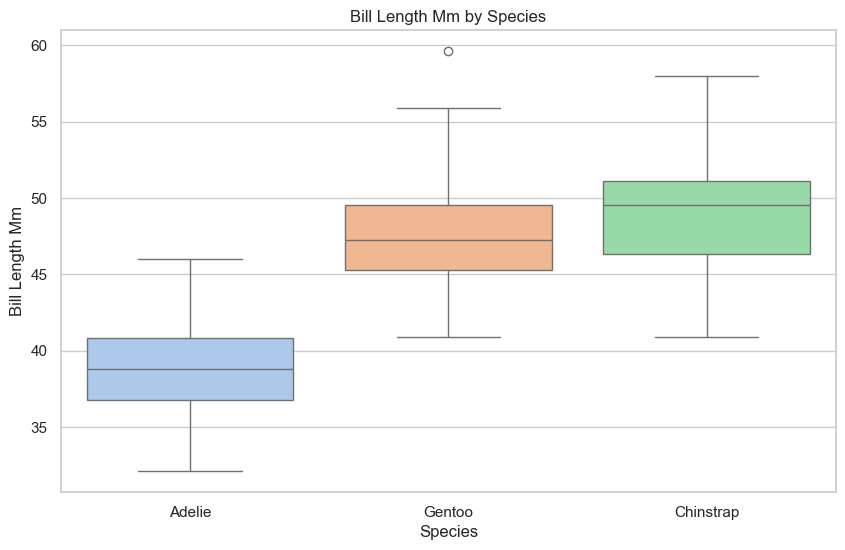

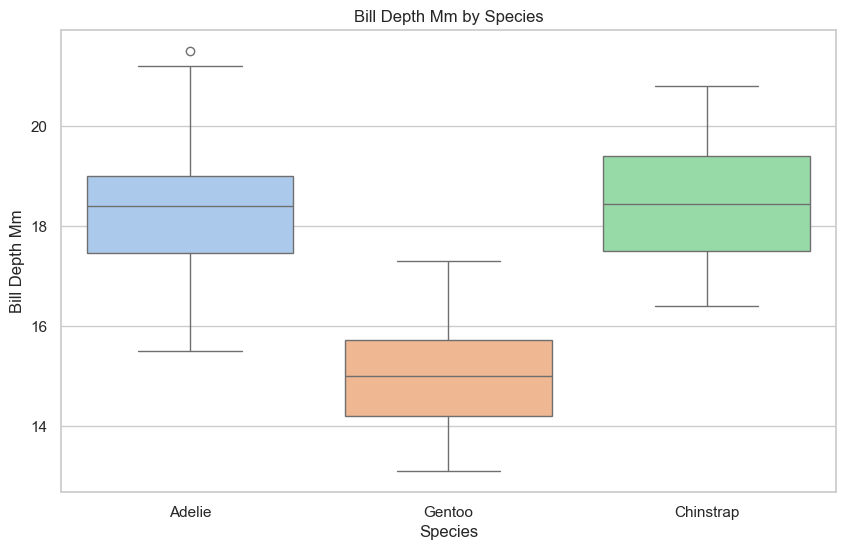

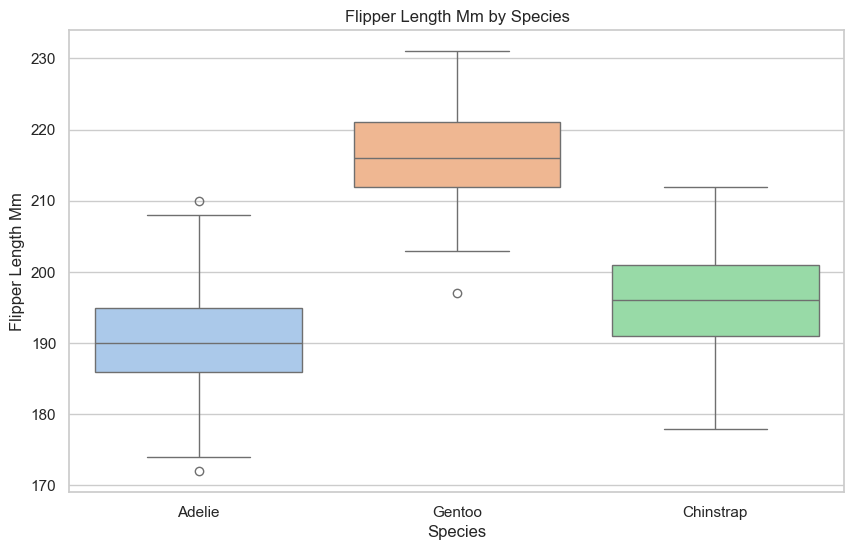

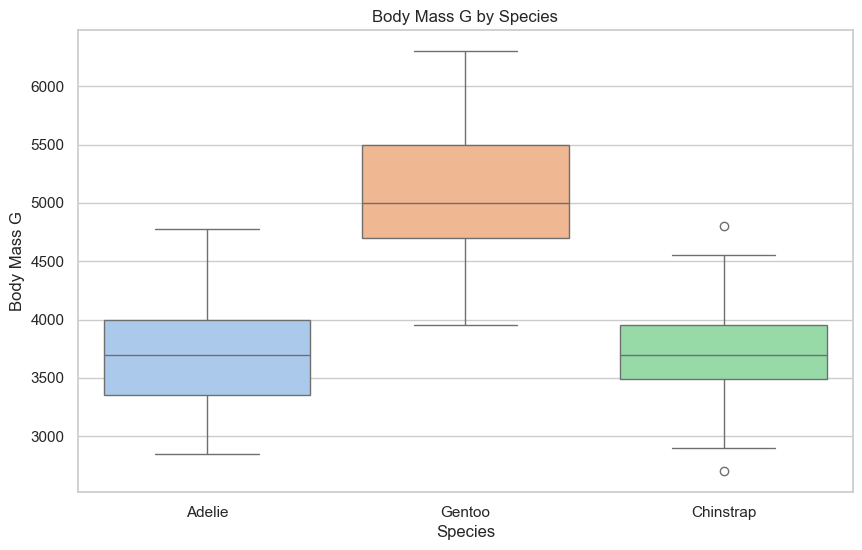

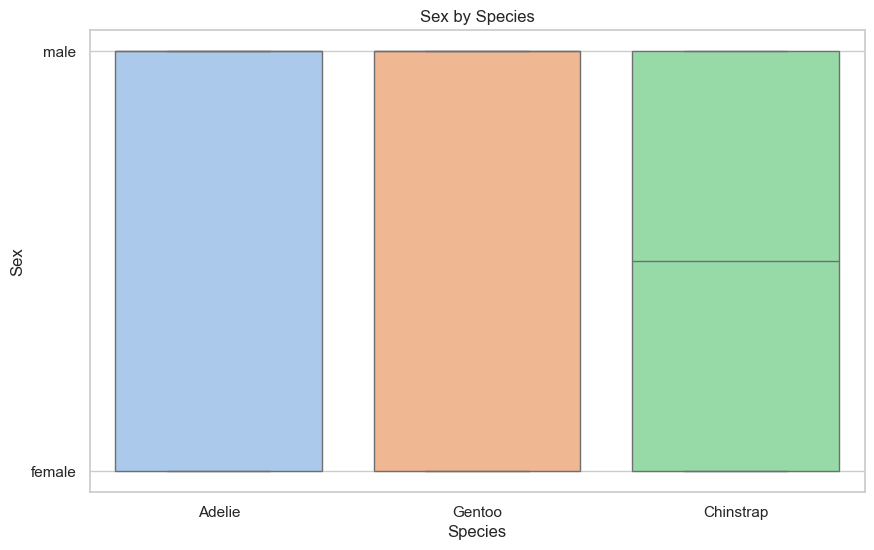

In [5]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
numerical_features = data.drop('species', axis=1).columns

#Boxplots
print("\n--- Feature Distributions by Species ---")
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='species', y=feature, data=data, palette='pastel', hue='species', legend=False)
    plt.title(f'{feature.replace("_", " ").title()} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature.replace("_", " ").title())
    plt.show()

### Correlation Heatmaps

Date: 2026-07-11

Student ID: DAMHAR2570

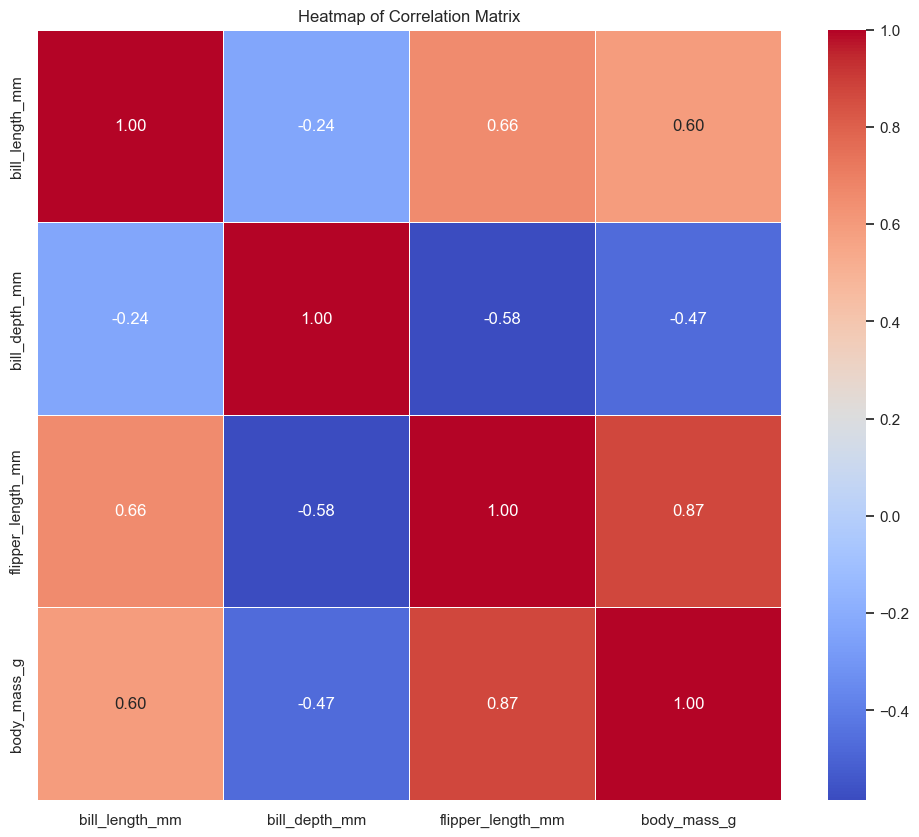

In [6]:
# Advanced Visualiztions
display(Markdown("### Correlation Heatmaps"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#Heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Heatmap of Correlation Matrix')
plt.show()


### Pair Plots for Feature Relationships

Date: 2026-07-11

Student ID: DAMHAR2570

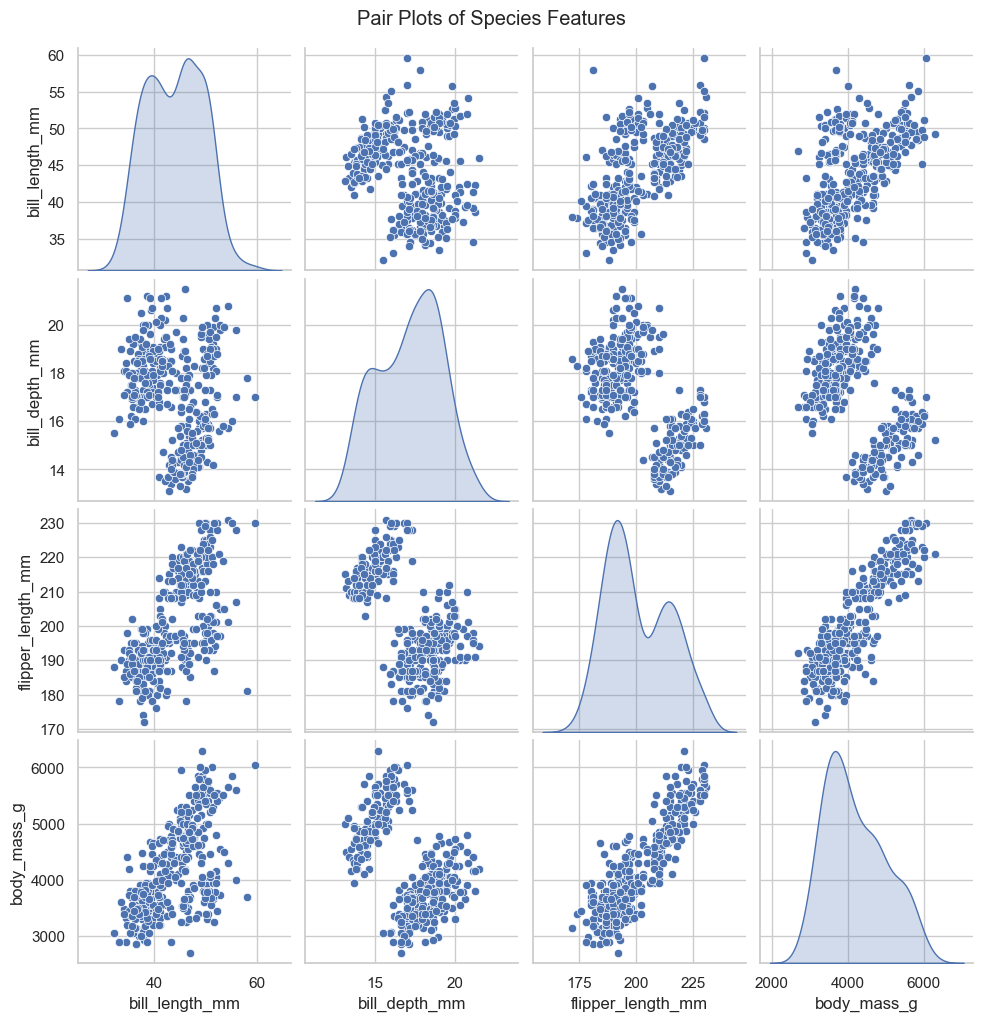

In [7]:

display(Markdown("### Pair Plots for Feature Relationships"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

features_to_plot = data.drop('species', axis=1)
pair_plot = sns.pairplot(features_to_plot, diag_kind='kde')
pair_plot.fig.suptitle("Pair Plots of Species Features", y=1.02)
plt.show()

### Bivariate vs Target Variable

Date: 2026-07-11

Student ID: DAMHAR2570

Correlation of each feature with Species:
flipper_length_mm    0.871221
bill_length_mm       0.595048
bill_depth_mm       -0.471942
Name: body_mass_g, dtype: float64


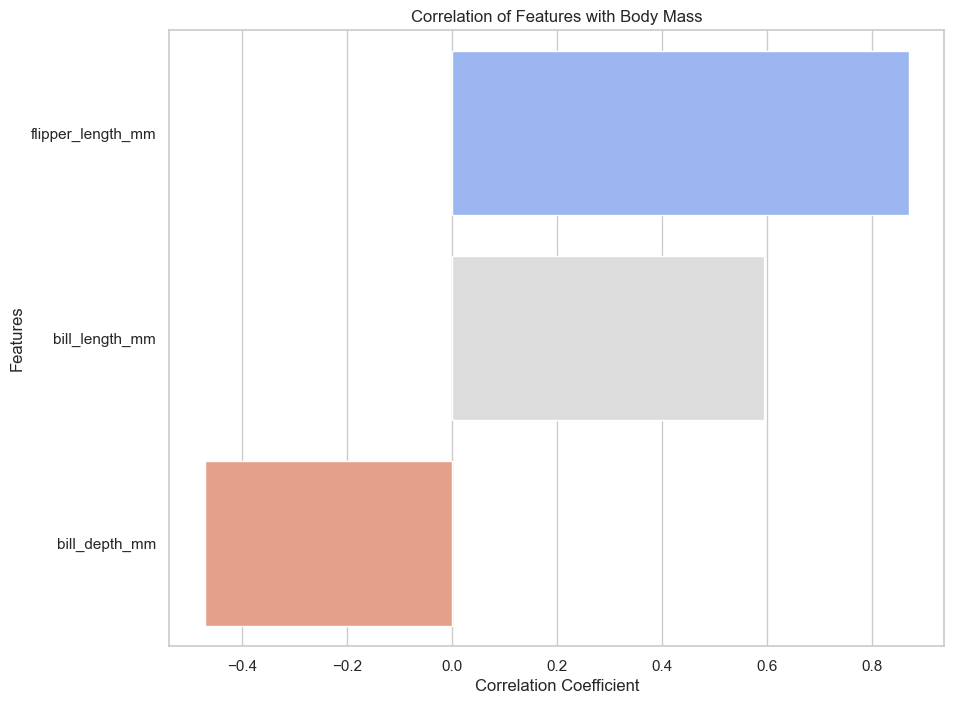

In [12]:
display(Markdown("### Bivariate vs Target Variable"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

body_mass_g_corr = data.corr(numeric_only=True)['body_mass_g'].drop('body_mass_g').sort_values(ascending=False)
print("Correlation of each feature with Species:")
print(species_corr)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=species_corr.values,
    y=species_corr.index,
    hue=species_corr.index,      # assign hue
    palette='coolwarm',
    legend=False                 # disable legend
)
plt.title('Correlation of Features with Body Mass')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()